# Введение

**Цель курсовой работы:** изучить культурную географии через создание геоинформационного моделирования персоналии, с акцентом на прослеживание пути текстов культуры и их создателя, исследовать механизмы коммеморации, а также создать базу данных для хранения и отображения информации о деятеле культуры, памятных местах и событиях.

**Задачи:**
1. Выбор персоналии для геоинформационного моделирования.
2. Исследование культурных текстов и их создателей.
3. Формирование набора данных.
4. Разработка алгоритмов сбора данных: Создание ДРАКОН-схем и алгоритмов для эффективного сбора и структурирования информации по персоналиям.
5. Проектирование базы данных.
6. Разработка запросов и программы для работы с базой данных.
7. Разработка интерфейса для работы с базой данных.
8. Оформление пояснительной записки (ПЗ).
9. Защита проекта.


**Этапы**

1. Выбор персоналии для геоинформационного моделирования:
   - Персоналия: Александр Иванович Герцен — российский писатель, общественный деятель, философ, автор революционных идей.
   - Утверждение выбора в системе ТУИС.
   - Создание файла с сопроводительной документацией в формате Markdown в JupyterLab.

2. Сбор информации о Герцене:
   - Изучение биографии Герцена, его влияния на литературу и общественные движения.
   - Поиск в различных источниках: дневники писателей, биографические словари, исторические документы, материалы музеев и выставок, базы данных, электронные ресурсы.
   - Прослеживание пути текстов культуры и произведений Герцена от его рождения до сегодняшнего дня.
   - Сбор информации о памятных местах, связанных с его жизнью (места проживания, учебы, важных в его жизни знакомств, места, где были написаны его произведения,  памятники и музеи).

3. Создание мультимедийных материалов:
   - Сбор изображений, аудио, видео, 3D-моделей, связанных с жизнью и деятельностью Герцена.
   - Формирование библиографических ссылок для каждого источника данных.

4. Создание алгоритмов сбора данных:
   - Разработка алгоритмов для эффективного сбора данных о Герцене.
   - Отображение алгоритмов в виде ДРАКОН-схем.

5. Написание литературной части работы.

6. Проектирование базы данных:
   - Классификация и систематизация собранных фактов о Герцене.
   - Проектирование структуры базы данных SQLite и построение ER-диаграммы в нотации Питера Чена.
   - Выполнение SQL-запросов на создание таблиц базы данных и обеспечение целостности данных.

7. Разработка SQL-запросов для работы с данными:
   - Написание SQL-запросов для выполнения операций CRUD с базой данных.
   - Создание запросов для отображения данных на карте, построения хронологических маршрутов, отображения мультимедийных данных по событиям, связанным с Герценом.

8. Разработка программы для работы с базой данных:
   - Написание программы для отображения и редактирования данных в базе через интерфейс JupyterLab.

9. Оформление пояснительной записки:
   - Оформление подробной пояснительной записки с описанием всех этапов работы и полученных результатов.

10. Защита проекта:
   - Подготовка проекта для защиты, включая электронную и распечатанную версию пояснительной записки и файл проекта в формате .ipynb.



# Основная часть
*ER-диаграмма базы данных*

**Основные сущности:**  
1. **Persons**  
   - Содержит данные о персоналиях (фамилия, имя, отчество, даты рождения/смерти, описание).  
   - Включает А.И. Герцена и его окружение (писатели, политики, соратники).  

2. **Sources**  
   - Хранит информацию о первоисточниках: название, автор, библиографическая ссылка, текстовое содержание.  

3. **Events**  
   - Описывает события из жизни Герцена (публикации, поездки, ссылки).  
   - Связана с **Dates** (даты начала/окончания) и **Sources** (источник данных).  

4. **Places**  
   - Привязывает события к географическим координатам через таблицу **Coordinates** (широта, долгота).  

5. **Texts**  
   - Содержит литературные произведения Герцена (название, текст, дата создания).  
   - Связана с **Persons**, **Sources** и **Dates**.  

6. **Interactions**  
   - Фиксирует взаимодействия Герцена с другими деятелями (описание, дата, участники).  

**Структура связей:**  
- **Один ко многим:**  
  - Один источник (**Sources**) - множество событий, текстов, взаимодействий.  
  - Одна дата (**Dates**) - множество событий, текстов.  
  - Одно место (**Places**) - множество событий.  

- **Внешние ключи:**  
  - События связаны с датами, источниками и местами.  
  - Тексты и взаимодействия привязаны к персоналиям и источникам.  

**Функционал:**  
- Обеспечивает хронологическое воспроизведение фактов.  
- Позволяет визуализировать маршруты Герцена на карте через связь **Events** - **Places** - **Coordinates**.  
- Поддерживает анализ культурного влияния через таблицу **Interactions**.    

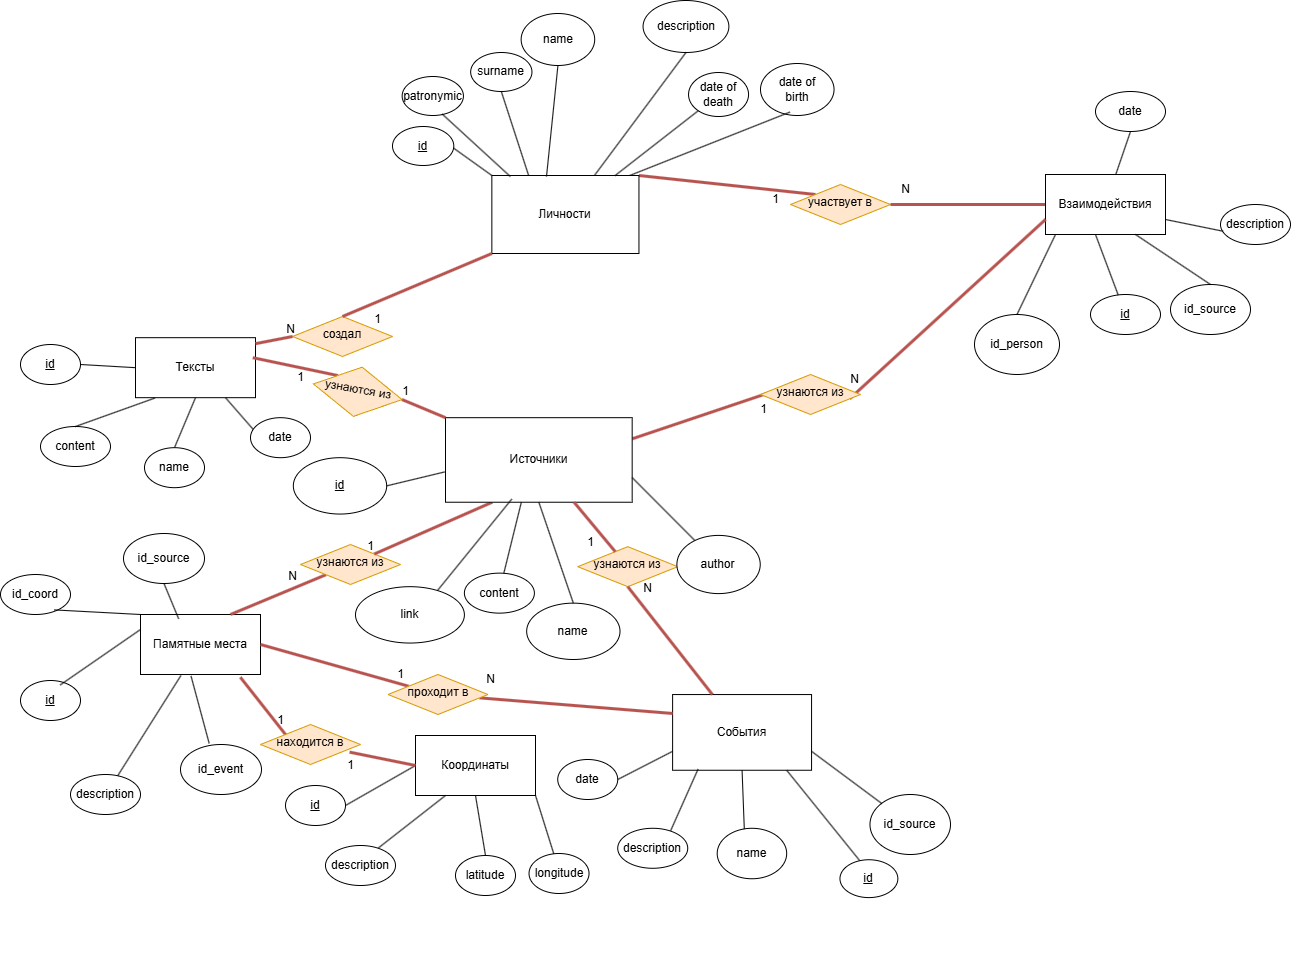


**ДРАКОН-схема сбора данных по персоналии** 

**Алгоритм (ДРАКОН-схема)**:  
   - Определение цели → Формулировка запросов → Выбор источников → Извлечение данных → Проверка достоверности → Структурирование в БД.  

Схема обеспечивает систематизацию данных, минимизацию ошибок и совместимость с SQLite.

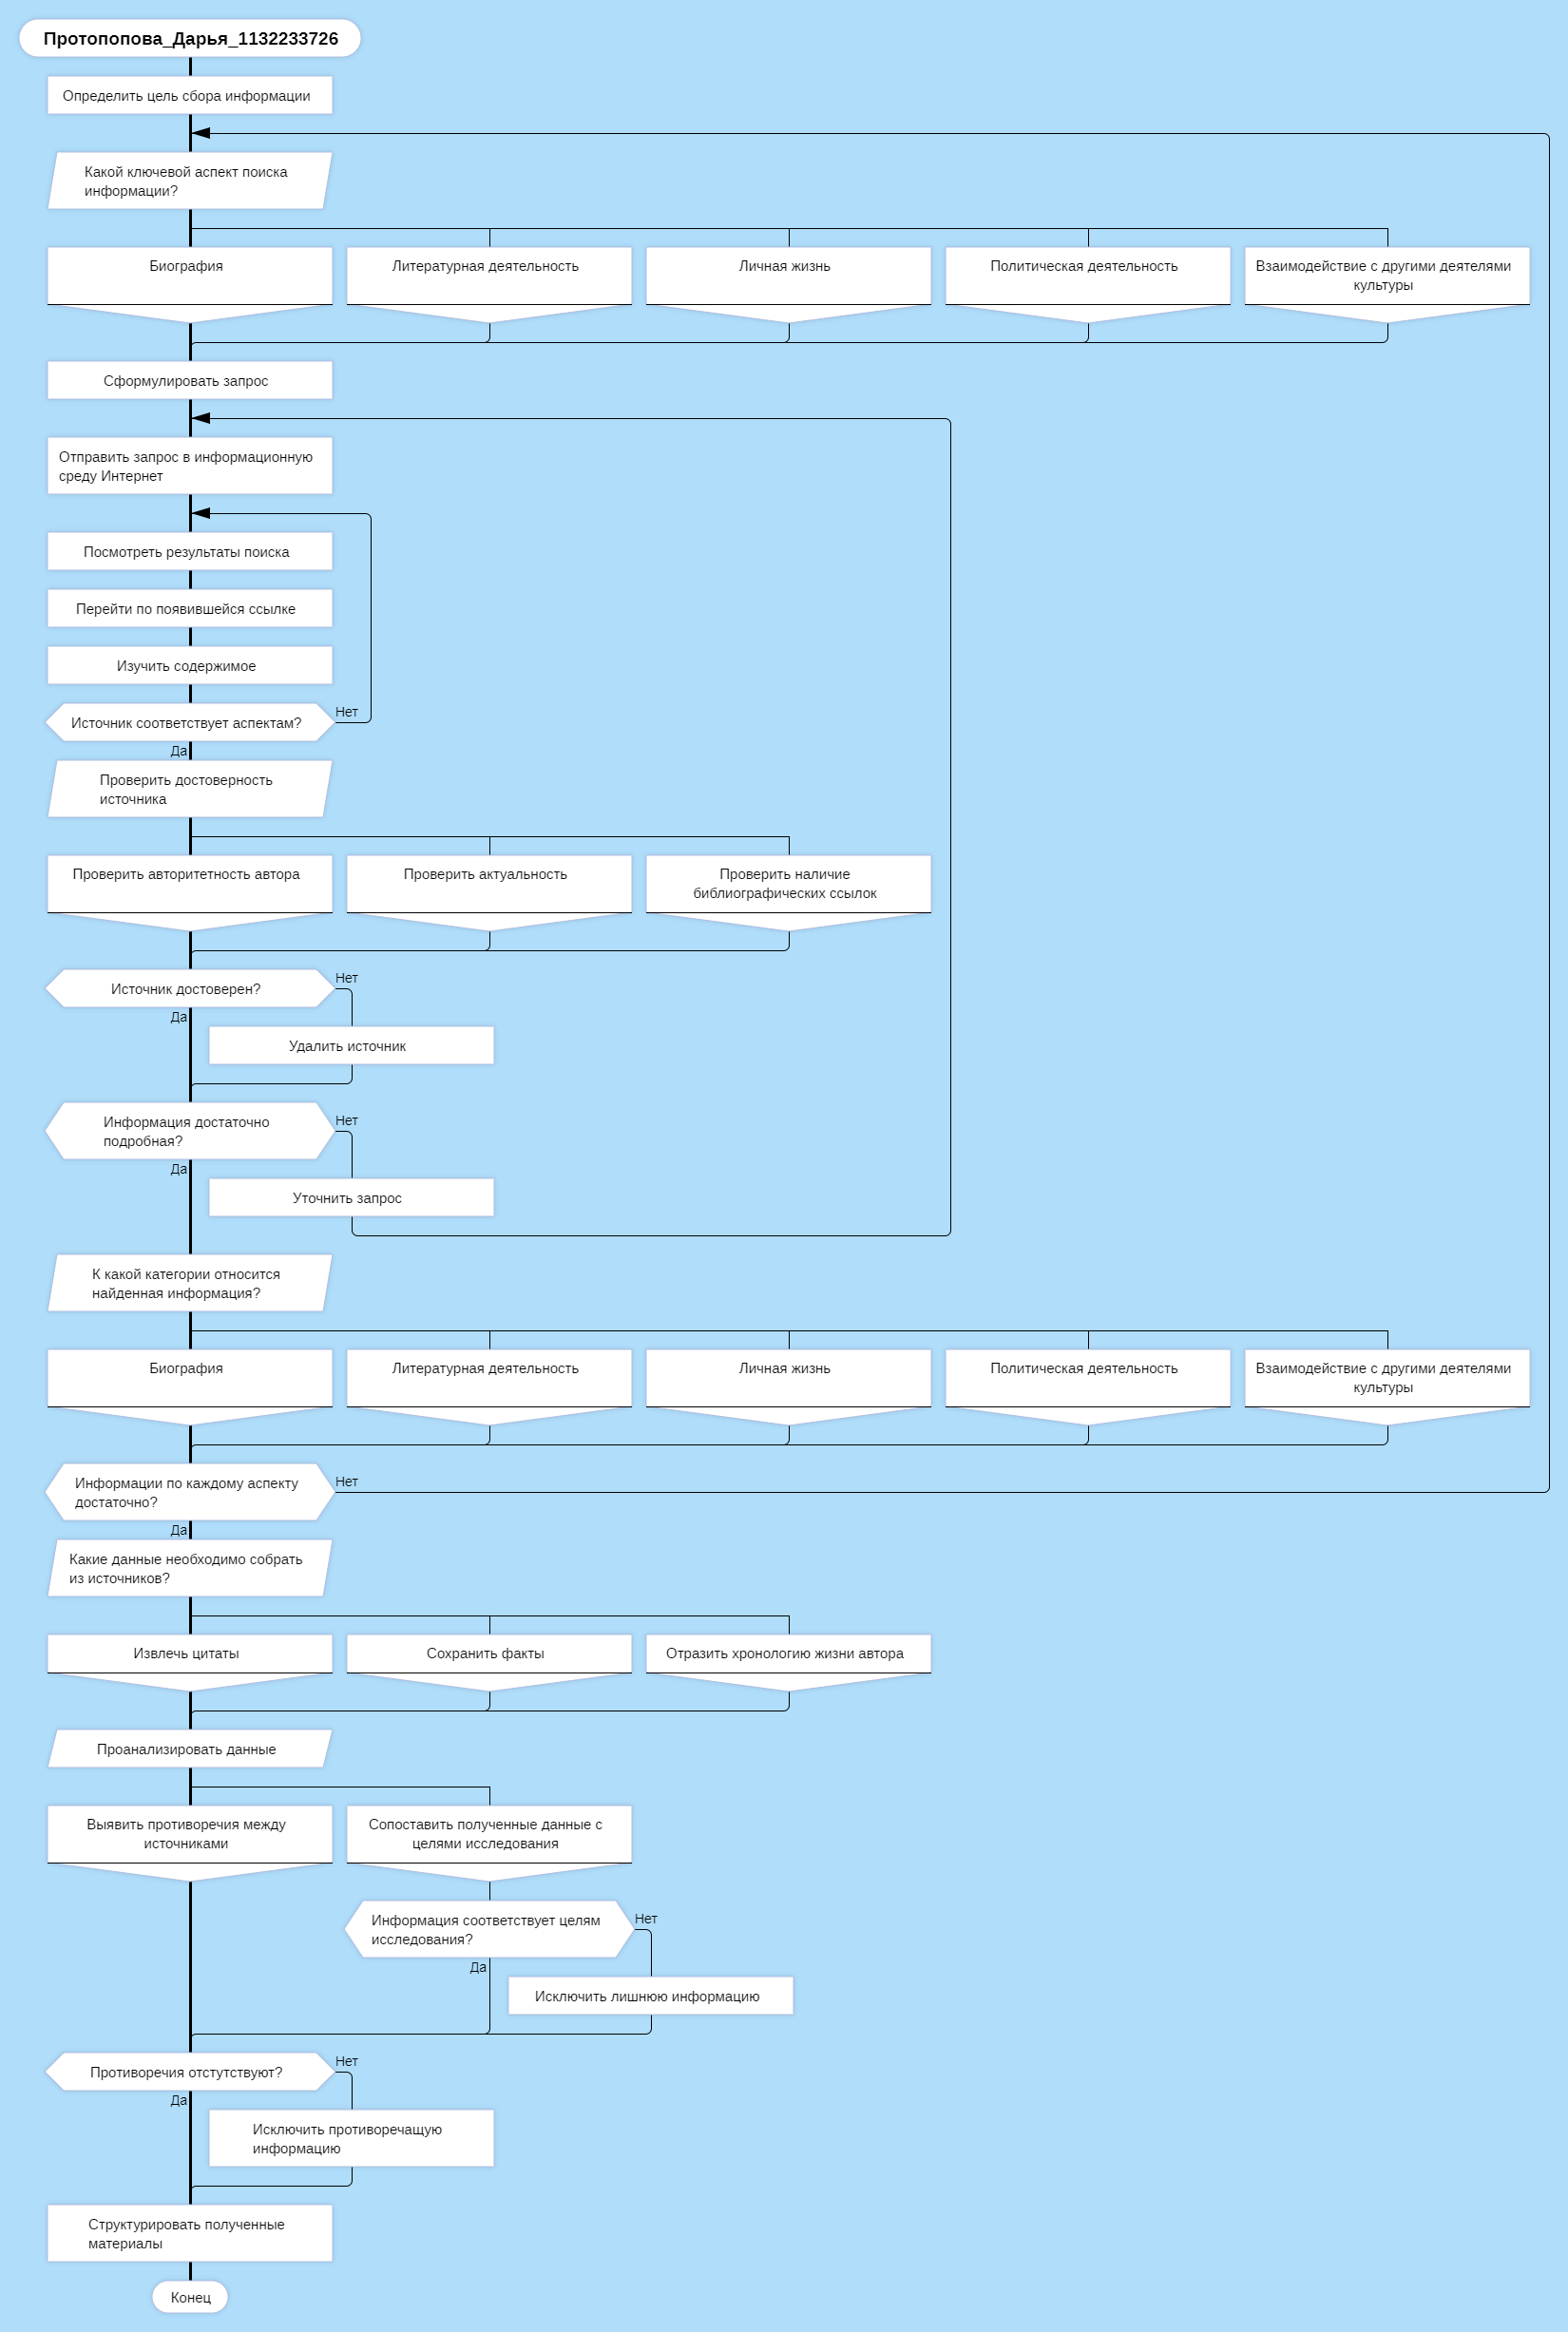

**Проектирование Базы данных и ее заполнение**
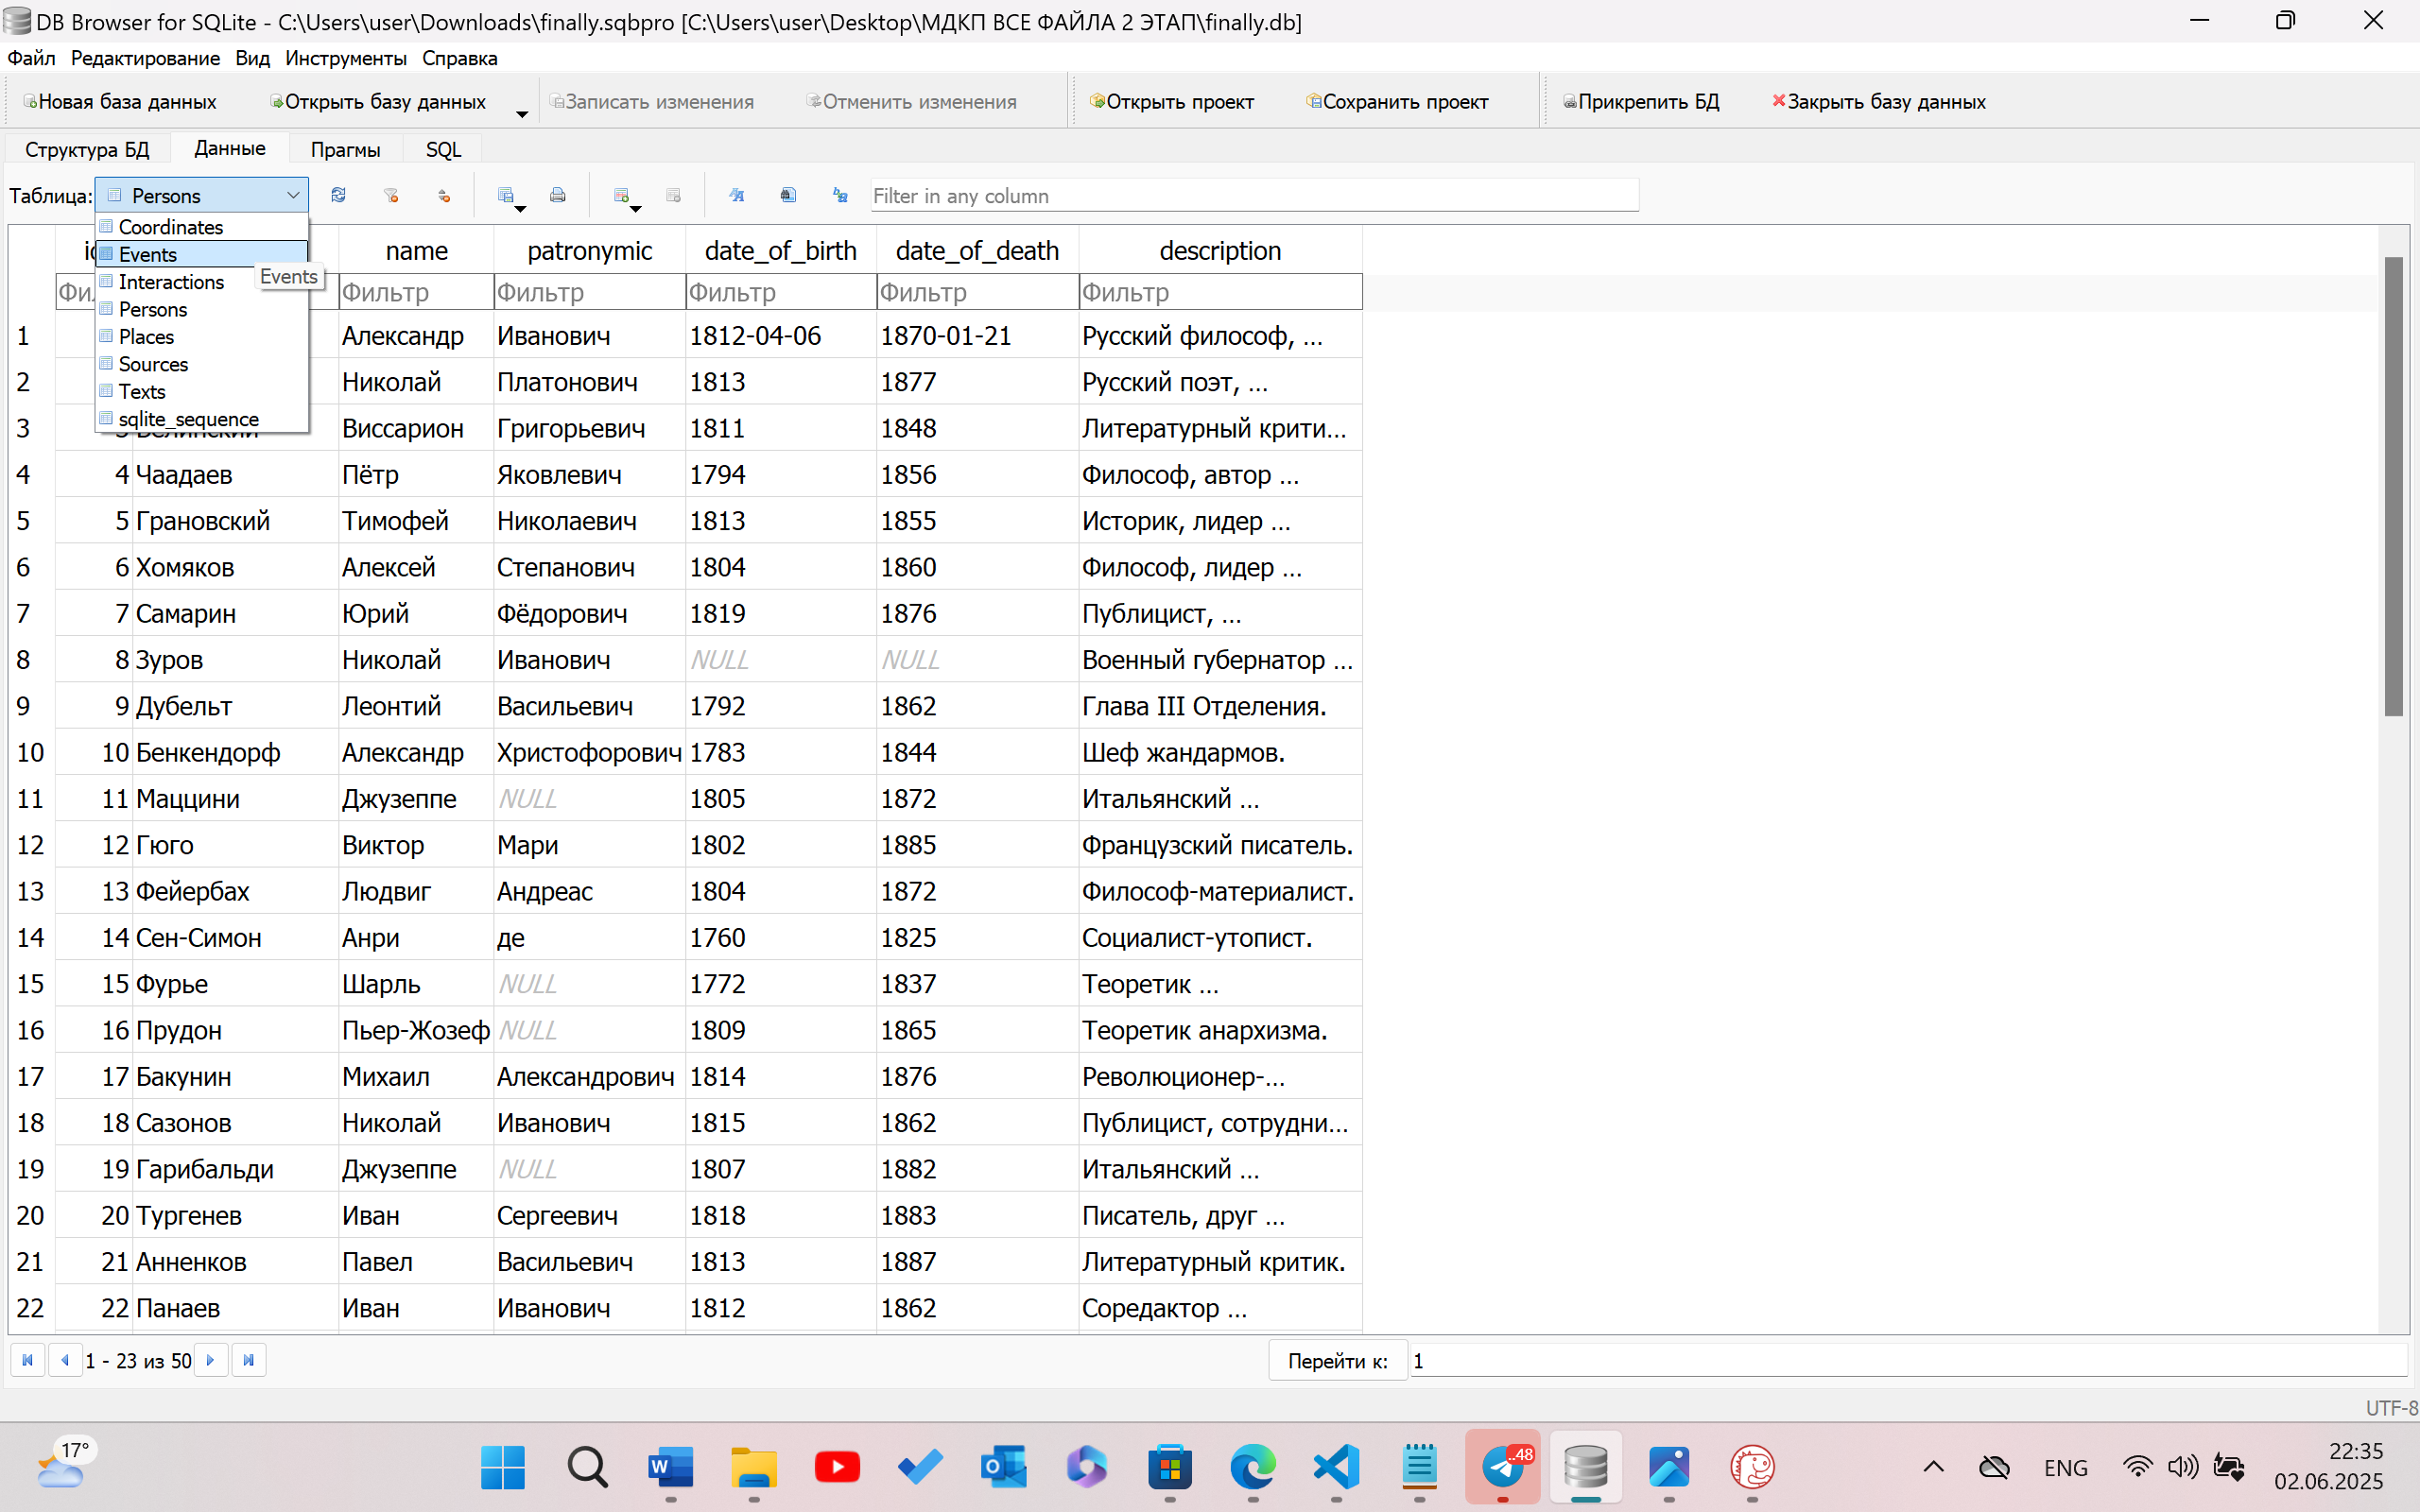
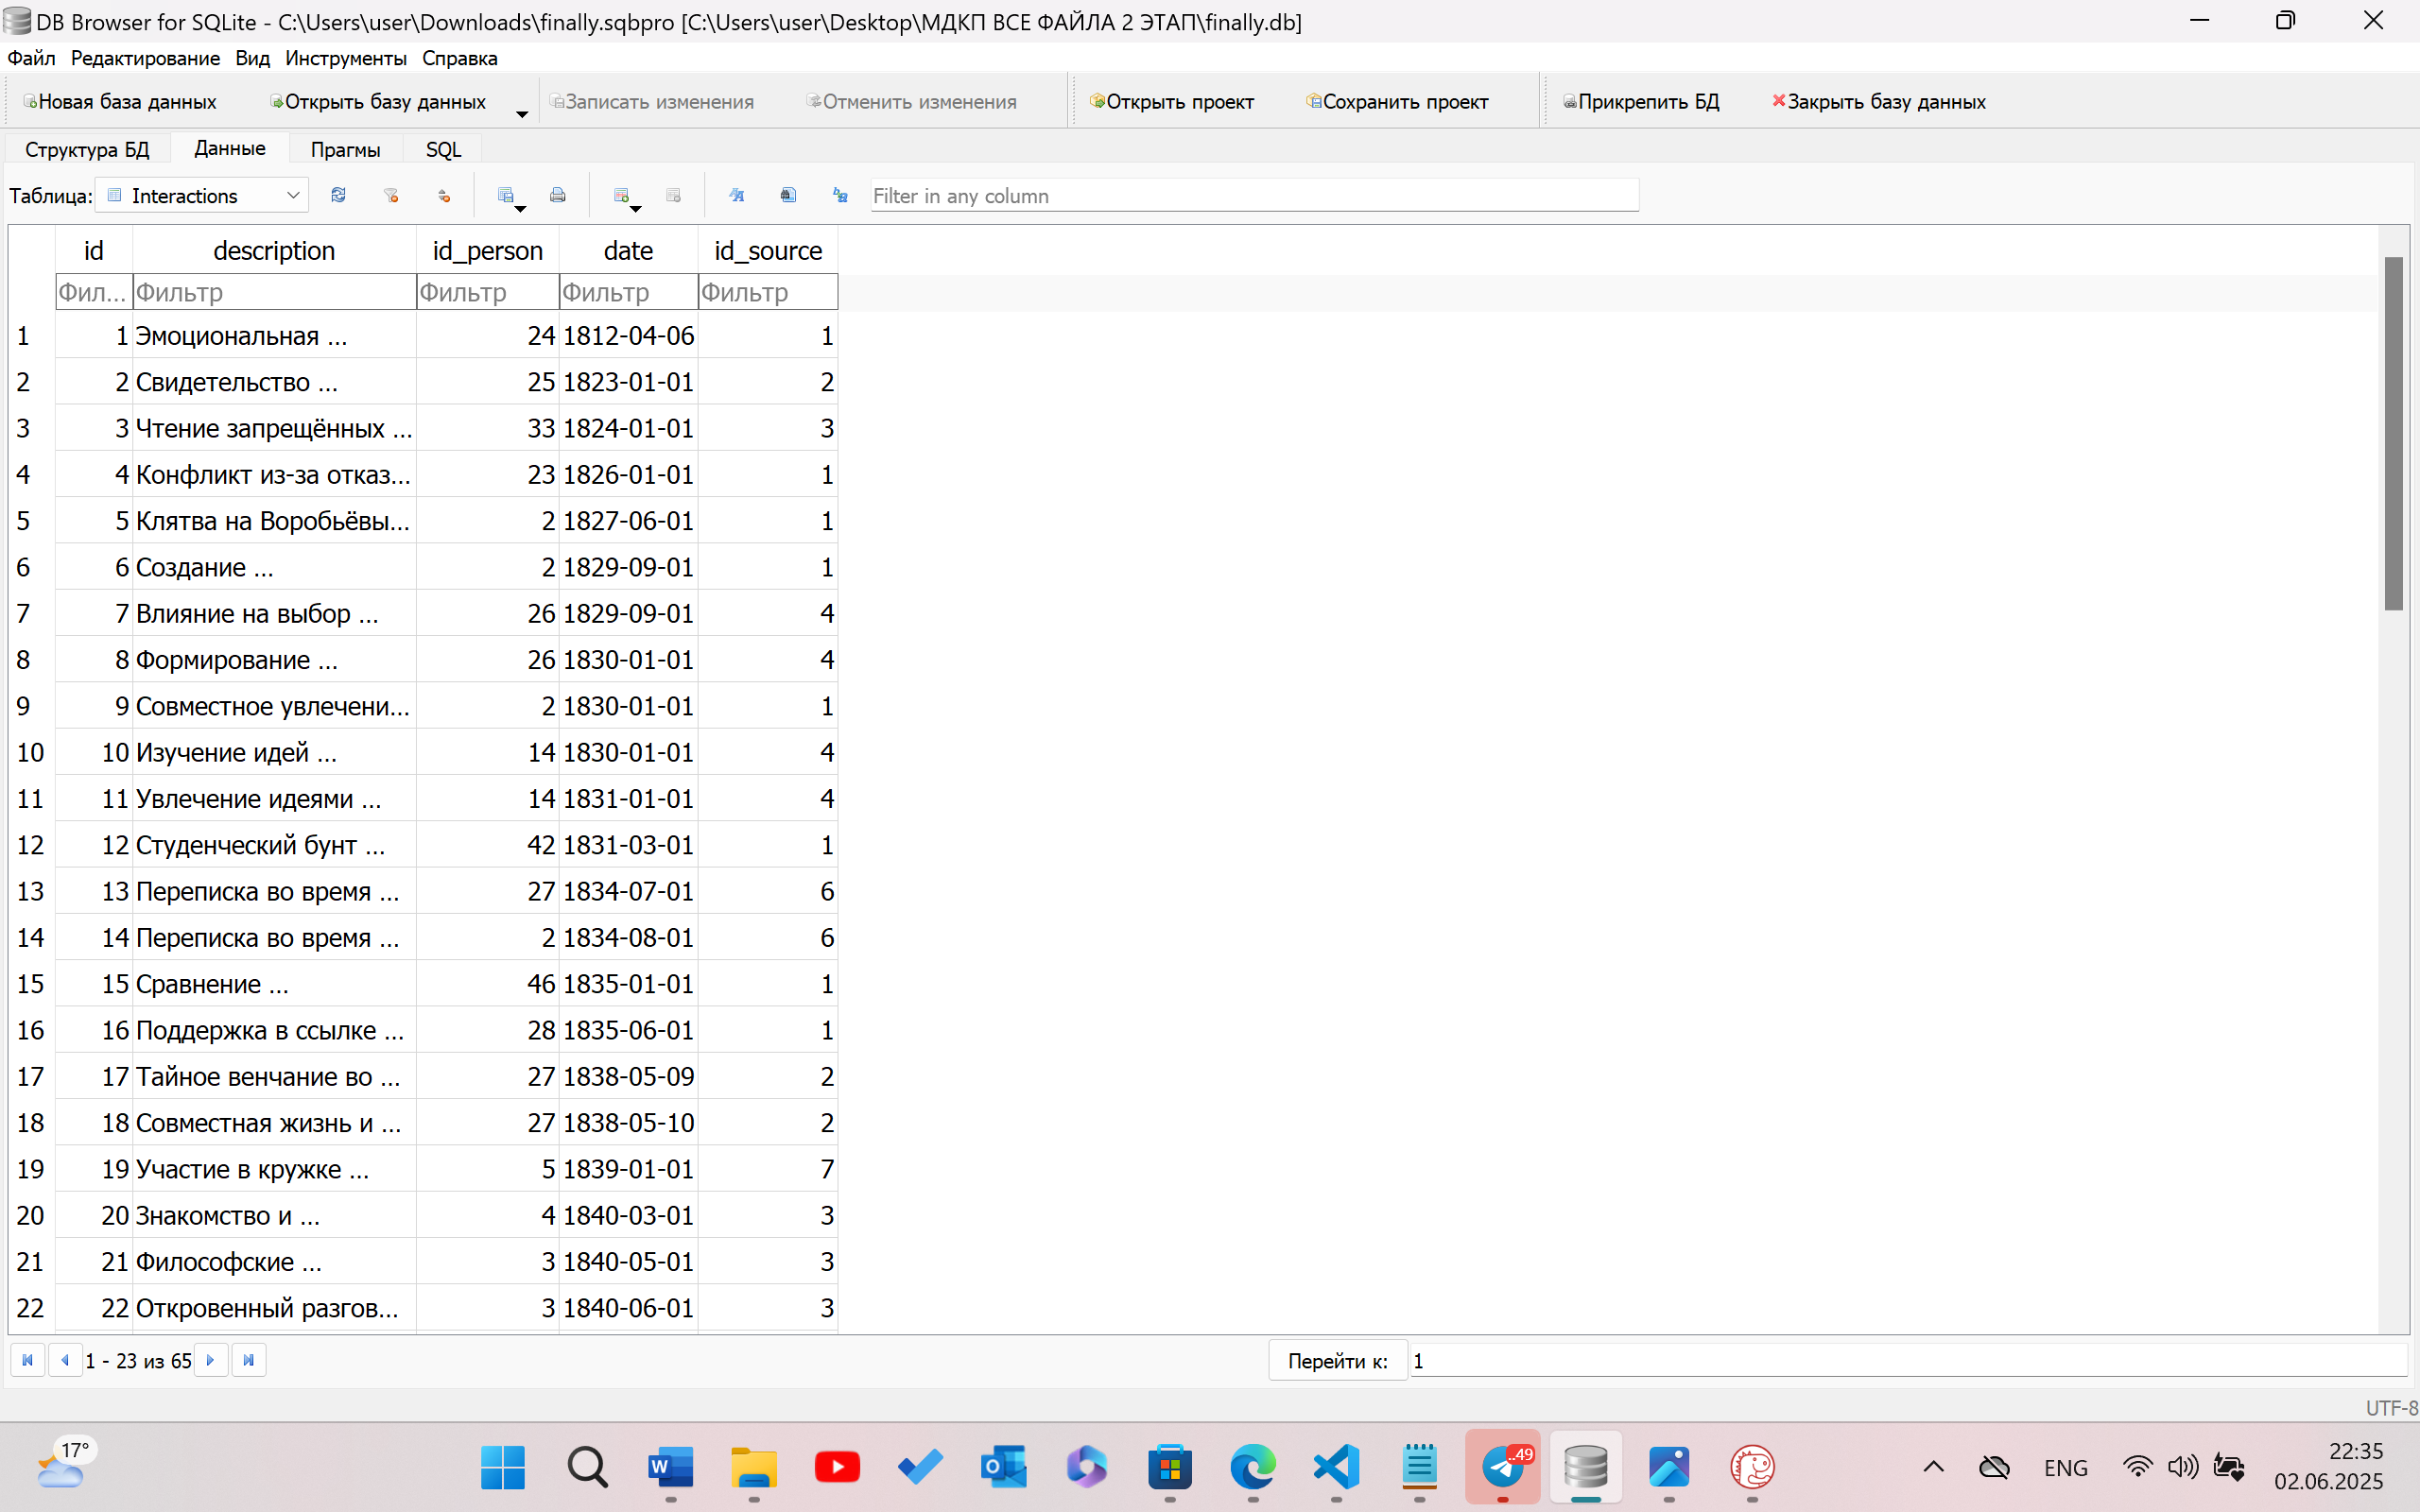
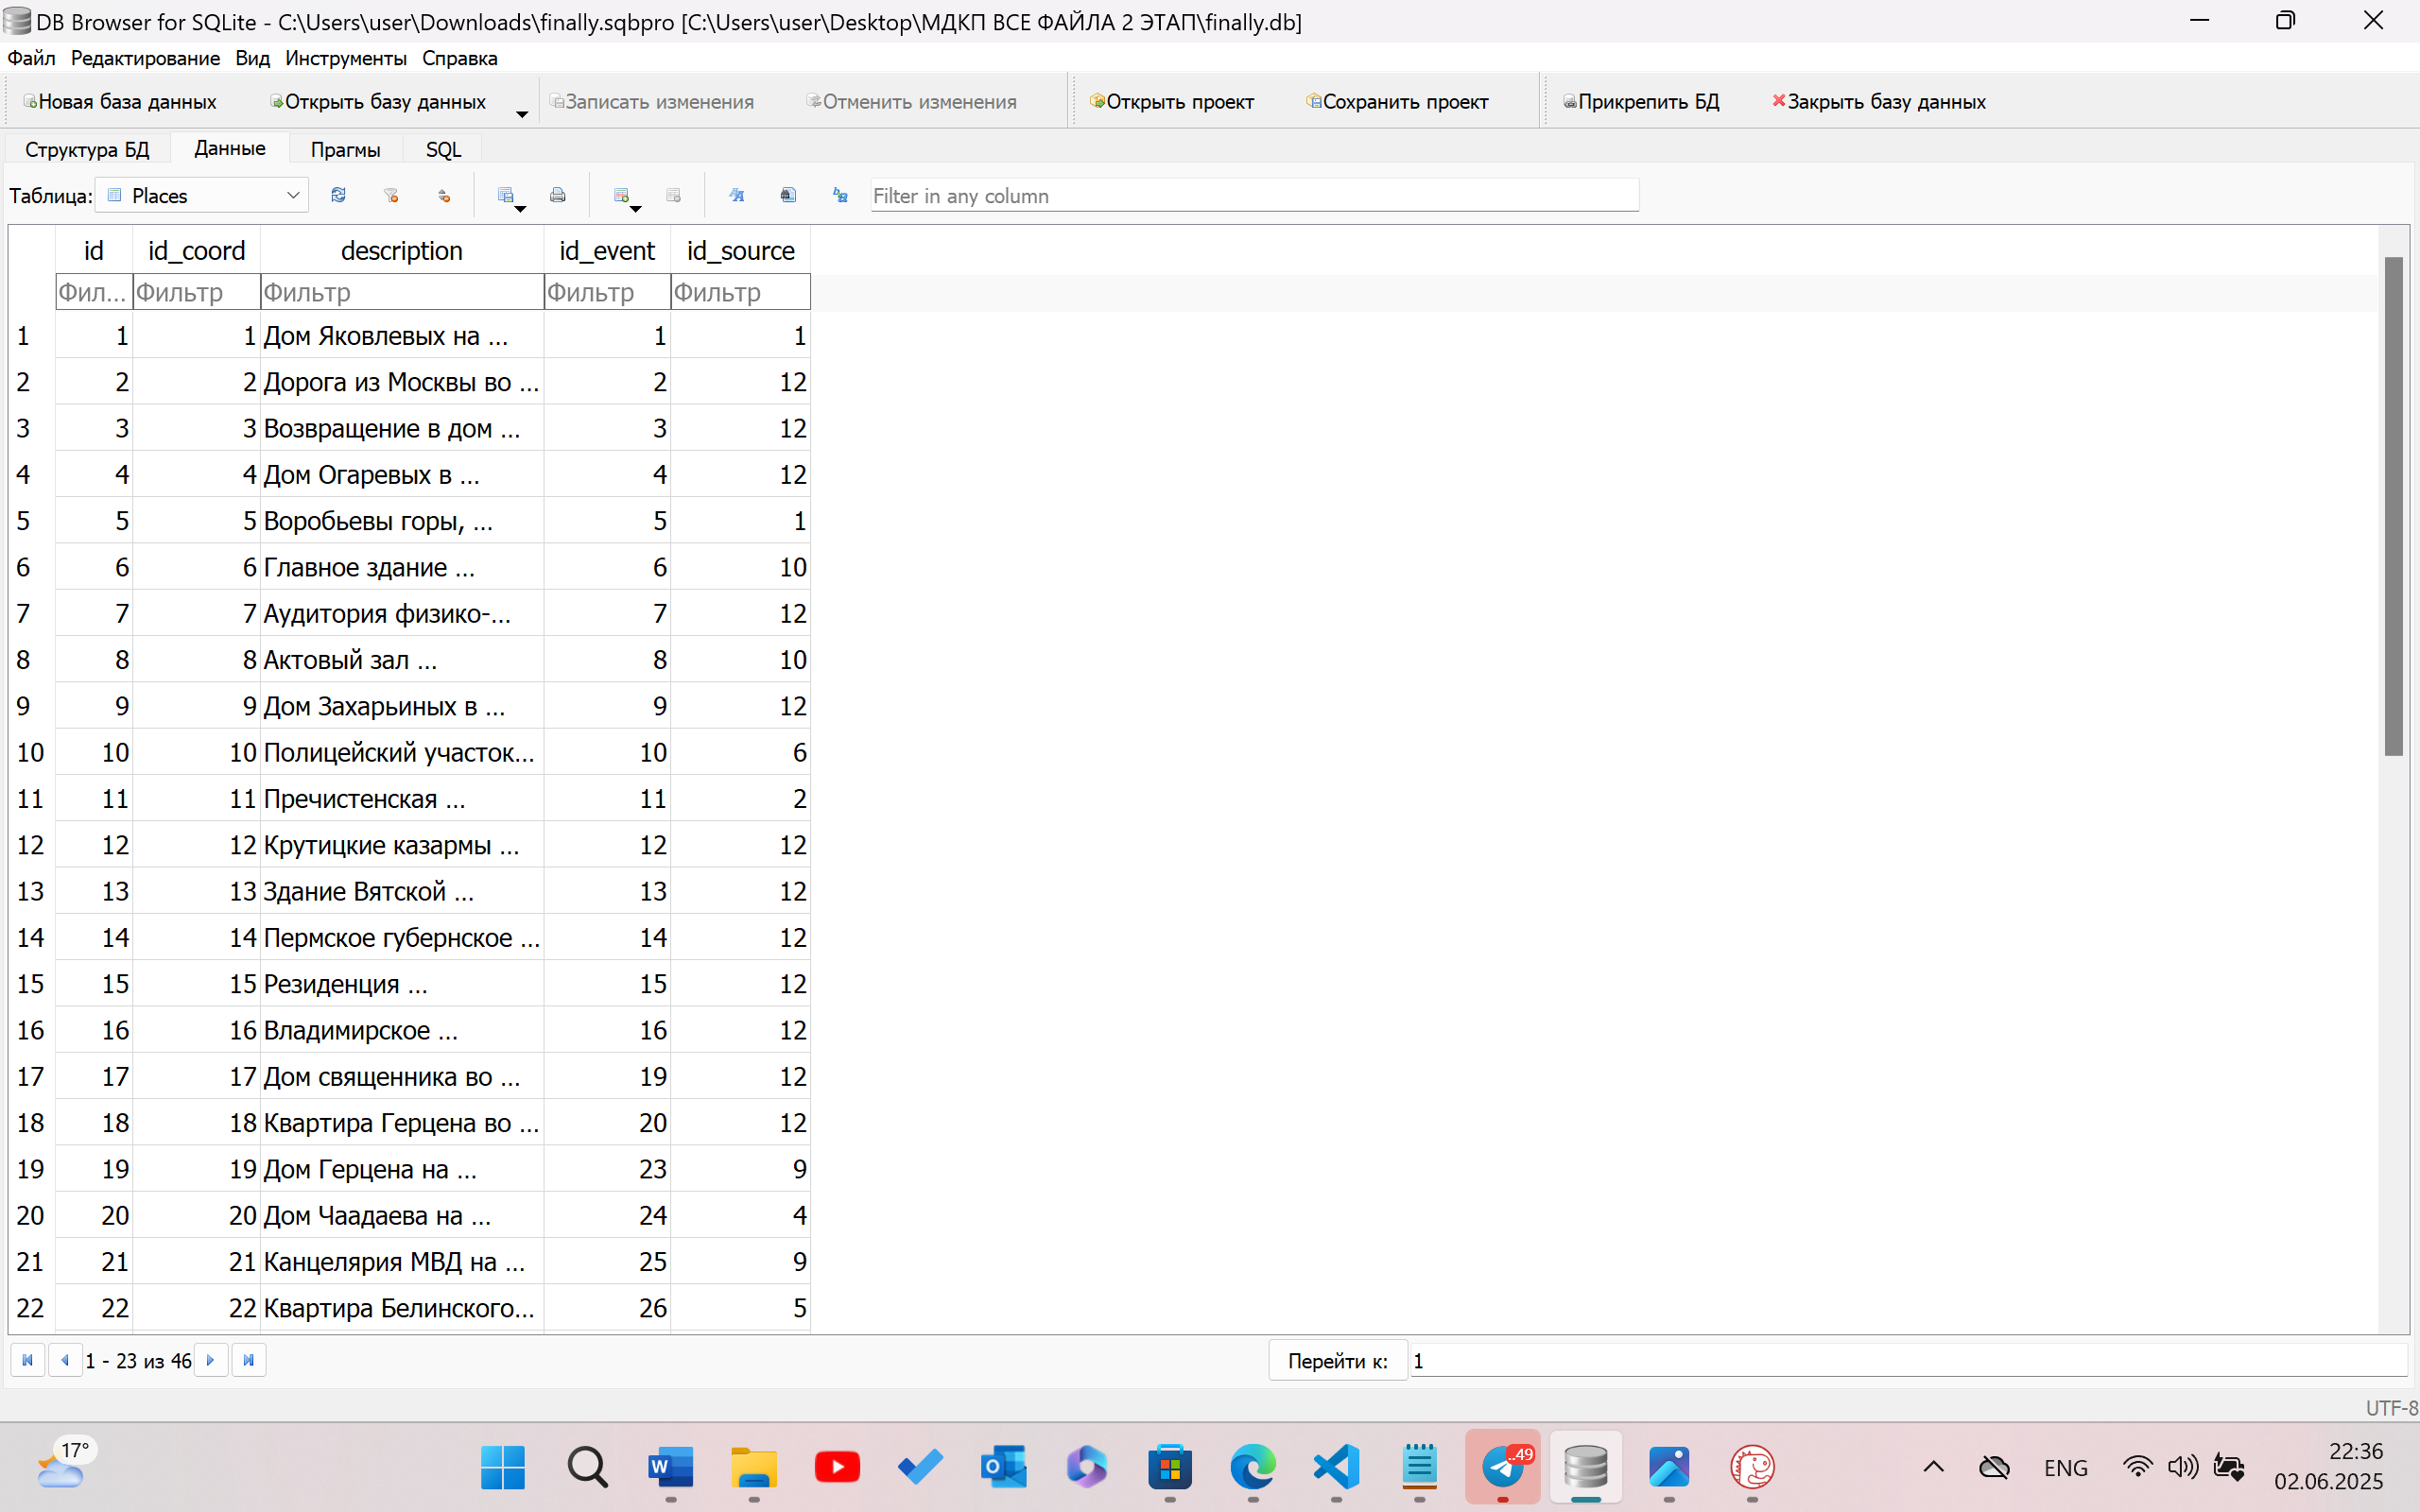

In [ ]:
import sqlite3

DATABASE_NAME = 'Протопопова_Дарья_1132233726.db'

def get_connection():
    return sqlite3.connect(DATABASE_NAME)

def list_records_with_join(table_name):
    conn = get_connection()
    cursor = conn.cursor()

    try:
        if table_name == "Events":
            cursor.execute("""
                SELECT Events.id, Events.name, Events.description, Events.date, Sources.name
                FROM Events
                LEFT JOIN Sources ON Events.id_source = Sources.id
            """)
            records = cursor.fetchall()
            print(f"\nСписок событий с названием источника:")
            print("id | name | description | date | source_name")
            for r in records:
                print(r)

        elif table_name == "Places":
            cursor.execute("""
                SELECT Places.id, Coordinates.latitude, Coordinates.longitude, Places.description,
                       Events.name, Sources.name
                FROM Places
                LEFT JOIN Coordinates ON Places.id_coord = Coordinates.id
                LEFT JOIN Events ON Places.id_event = Events.id
                LEFT JOIN Sources ON Places.id_source = Sources.id
            """)
            records = cursor.fetchall()
            print(f"\nСписок мест с координатами, событием и источником:")
            print("id | latitude | longitude | place_description | event_name | source_name")
            for r in records:
                print(r)

        elif table_name == "Interactions":
            cursor.execute("""
                SELECT Interactions.id, Interactions.description, Persons.surname, Persons.name,
                       Interactions.date, Sources.name
                FROM Interactions
                LEFT JOIN Persons ON Interactions.id_person = Persons.id
                LEFT JOIN Sources ON Interactions.id_source = Sources.id
            """)
            records = cursor.fetchall()
            print(f"\nСписок взаимодействий с именами лиц и источниками:")
            print("id | description | person_surname | person_name | date | source_name")
            for r in records:
                print(r)

        elif table_name == "Persons":
            cursor.execute("SELECT * FROM Persons")
            records = cursor.fetchall()
            print("\nСписок лиц:")
            print("id | surname | name | patronymic | date_of_birth | date_of_death | description")
            for r in records:
                print(r)

        elif table_name == "Sources":
            cursor.execute("SELECT * FROM Sources")
            records = cursor.fetchall()
            print("\nСписок источников:")
            print("id | name | link | author | content")
            for r in records:
                print(r)

        elif table_name == "Coordinates":
            cursor.execute("SELECT * FROM Coordinates")
            records = cursor.fetchall()
            print("\nСписок координат:")
            print("id | latitude | longitude | description")
            for r in records:
                print(r)

        elif table_name == "Texts":
            cursor.execute("SELECT * FROM Texts")
            records = cursor.fetchall()
            print("\nСписок текстов:")
            print("id | name | content | date")
            for r in records:
                print(r)

        else:
            print(f"Вывод с JOIN не реализован для таблицы {table_name}")
    except Exception as e:
        print(f"Ошибка при получении данных из {table_name}: {e}")
    finally:
        conn.close()

def get_record(table_name, id_name, record_id):
    try:
        conn = get_connection()
        cursor = conn.cursor()
        cursor.execute(f"SELECT * FROM {table_name} WHERE {id_name} = ?", (record_id,))
        record = cursor.fetchone()
        if record:
            print(f"\nДанные записи из {table_name} с {id_name}={record_id}:")
            print(record)
        else:
            print(f"Запись с {id_name}={record_id} в таблице {table_name} не найдена.")
    except Exception as e:
        print(f"Ошибка при получении записи: {e}")
    finally:
        conn.close()

def add_record(table_name, fields):
    print(f"\nДобавление новой записи в {table_name}:")
    values = []
    for field in fields:
        val = input(f"{field}: ")
        if val == "":
            val = None
        values.append(val)
    placeholders = ", ".join("?" for _ in fields)
    fields_str = ", ".join(fields)
    try:
        conn = get_connection()
        cursor = conn.cursor()
        cursor.execute(f"INSERT INTO {table_name} ({fields_str}) VALUES ({placeholders})", values)
        conn.commit()
        print(f"Запись успешно добавлена с ID: {cursor.lastrowid}")
    except Exception as e:
        print(f"Ошибка при добавлении записи: {e}")
    finally:
        conn.close()

def update_record(table_name, id_name, record_id, fields):
    try:
        conn = get_connection()
        cursor = conn.cursor()
        cursor.execute(f"SELECT * FROM {table_name} WHERE {id_name} = ?", (record_id,))
        record = cursor.fetchone()
        if not record:
            print(f"Запись с {id_name}={record_id} не найдена.")
            return

        print("Введите новые значения полей (оставьте пустым, чтобы не менять):")
        new_values = []
        for i, field in enumerate(fields, start=1):  # start=1 because record[0] — id
            old_value = record[i]
            val = input(f"{field} (текущее: {old_value}): ")
            if val == "":
                val = old_value
            new_values.append(val)
        set_clause = ", ".join(f"{field} = ?" for field in fields)
        new_values.append(record_id)
        cursor.execute(f"UPDATE {table_name} SET {set_clause} WHERE {id_name} = ?", new_values)
        conn.commit()
        print("Запись успешно обновлена.")
    except Exception as e:
        print(f"Ошибка при обновлении записи: {e}")
    finally:
        conn.close()

def delete_record(table_name, id_name, record_id):
    try:
        conn = get_connection()
        cursor = conn.cursor()
        cursor.execute(f"SELECT * FROM {table_name} WHERE {id_name} = ?", (record_id,))
        record = cursor.fetchone()
        if not record:
            print(f"Запись с {id_name}={record_id} не найдена.")
            return
        cursor.execute(f"DELETE FROM {table_name} WHERE {id_name} = ?", (record_id,))
        conn.commit()
        print("Запись успешно удалена.")
    except Exception as e:
        print(f"Ошибка при удалении записи: {e}")
    finally:
        conn.close()

def crud_menu(table_name, id_name, fields):
    while True:
        print(f"""
Меню управления таблицей {table_name}:
1. Просмотреть все записи
2. Найти запись по {id_name}
3. Добавить запись
4. Обновить запись
5. Удалить запись
0. Назад
""")
        choice = input("Выберите действие: ")
        if choice == "1":
            if table_name in ["Events", "Places", "Interactions"]:
                list_records_with_join(table_name)
            else:
                conn = get_connection()
                cursor = conn.cursor()
                cursor.execute(f"SELECT * FROM {table_name}")
                records = cursor.fetchall()
                print(f"\nЗаписи из таблицы {table_name}:")
                for record in records:
                    print(record)
                conn.close()
        elif choice == "2":
            record_id = input(f"Введите {id_name} записи: ")
            get_record(table_name, id_name, record_id)
        elif choice == "3":
            add_record(table_name, fields)
        elif choice == "4":
            record_id = input(f"Введите {id_name} записи для обновления: ")
            update_record(table_name, id_name, record_id, fields)
        elif choice == "5":
            record_id = input(f"Введите {id_name} записи для удаления: ")
            delete_record(table_name, id_name, record_id)
        elif choice == "0":
            break
        else:
            print("Неверный выбор. Попробуйте снова.")

def main():
    while True:
        print("""
Выберите таблицу для управления:
1. Persons (Люди)
2. Sources (Источники)
3. Events (События)
4. Coordinates (Координаты)
5. Places (Места)
6. Texts (Тексты)
7. Interactions (Взаимодействия)
0. Выход
""")
        choice = input("Введите номер: ")
        if choice == "0":
            print("Выход из программы.")
            break
        elif choice == "1":
            crud_menu(
                "Persons", "id",
                ["surname", "name", "patronymic", "date_of_birth", "date_of_death", "description"]
            )
        elif choice == "2":
            crud_menu(
                "Sources", "id",
                ["name", "link", "author", "content"]
            )
        elif choice == "3":
            crud_menu(
                "Events", "id",
                ["name", "description", "date", "id_source"]
            )
        elif choice == "4":
            crud_menu(
                "Coordinates", "id",
                ["latitude", "longitude", "description"]
            )
        elif choice == "5":
            crud_menu(
                "Places", "id",
                ["id_coord", "description", "id_event", "id_source"]
            )
        elif choice == "6":
            crud_menu(
                "Texts", "id",
                ["name", "content", "date"]
            )
        elif choice == "7":
            crud_menu(
                "Interactions", "id",
                ["description", "id_person", "date", "id_source"]
            )
        else:
            print("Неверный выбор. Попробуйте снова.")

if __name__ == "__main__":
    main()



Выберите таблицу для управления:
1. Persons (Люди)
2. Sources (Источники)
3. Events (События)
4. Coordinates (Координаты)
5. Places (Места)
6. Texts (Тексты)
7. Interactions (Взаимодействия)
0. Выход



### Разработка кода для работы с данными

Создана Python-программа для управления реляционной БД SQLite (файл Протопопова_Дарья_1132233726.db). Реализованы CRUD-операции для 7 таблиц: Persons, Sources, Events, Coordinates, Places, Texts, Interactions.

**Ключевые функции:**
- get_connection() - подключение к БД
- list_records_with_join() - вывод данных с JOIN для таблиц Events, Places, Interactions (которые связаны с другими таблицами внешним ключом)
- get_record() - поиск записи по ID
- add_record() - добавление записей с обработкой NULL-значений
- update_record() - редактирование с сохранением неизменных полей
- delete_record() - удаление с предварительной проверкой